# ЛР1 (CV): Демо-ноутбук для сдачи (helmet)

Этот notebook дополняет основной пайплайн на `.py` и нужен для быстрой демонстрации результатов.

Что делает ноутбук:
- проверяет наличие обученной модели и данных;
- показывает итоговые метрики из `metrics_summary.json`;
- строит графики обучения из `results.csv`;
- запускает инференс на части тестовых изображений;
- показывает примеры предсказаний прямо в notebook.

In [9]:
import importlib
import subprocess
import sys


def ensure_pkg(pkg_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(pkg_name)
    except ImportError:
        name = pip_name or pkg_name
        print(f"Устанавливаю пакет: {name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])


ensure_pkg("ultralytics")
ensure_pkg("yaml", "PyYAML")
ensure_pkg("pandas")
ensure_pkg("matplotlib")
ensure_pkg("PIL", "Pillow")

print("Окружение готово.")

Окружение готово.


In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from ultralytics import YOLO

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
RUN_DIR = ROOT / "runs" / "train" / "helmet_detector_gpu_final"
WEIGHTS = RUN_DIR / "weights" / "best.pt"
METRICS_JSON = RUN_DIR / "metrics_summary.json"
RESULTS_CSV = RUN_DIR / "results.csv"
TEST_IMAGES = ROOT / "dataset" / "test" / "images"
PREDICT_DIR = ROOT / "runs" / "predict" / "notebook_demo_helmet"

print(f"ROOT: {ROOT}")

ROOT: c:\Users\Egor2\Учёба\ИИ\Lab_1


In [11]:
checks = {
    "Модель best.pt": WEIGHTS,
    "Файл метрик": METRICS_JSON,
    "CSV обучения": RESULTS_CSV,
    "Папка тестовых изображений": TEST_IMAGES,
}

for label, path in checks.items():
    print(f"{label}: {'OK' if path.exists() else 'НЕ НАЙДЕНО'} -> {path}")

Модель best.pt: OK -> c:\Users\Egor2\Учёба\ИИ\Lab_1\runs\train\helmet_detector_gpu_final\weights\best.pt
Файл метрик: OK -> c:\Users\Egor2\Учёба\ИИ\Lab_1\runs\train\helmet_detector_gpu_final\metrics_summary.json
CSV обучения: OK -> c:\Users\Egor2\Учёба\ИИ\Lab_1\runs\train\helmet_detector_gpu_final\results.csv
Папка тестовых изображений: OK -> c:\Users\Egor2\Учёба\ИИ\Lab_1\dataset\test\images


In [12]:
with METRICS_JSON.open("r", encoding="utf-8") as f:
    summary = json.load(f)

metrics = summary.get("metrics", {})
print("Итоговые метрики (test):")
print(f"Precision:  {metrics.get('metrics/precision(B)', float('nan')):.6f}")
print(f"Recall:     {metrics.get('metrics/recall(B)', float('nan')):.6f}")
print(f"mAP50:      {metrics.get('metrics/mAP50(B)', float('nan')):.6f}")
print(f"mAP50-95:   {metrics.get('metrics/mAP50-95(B)', float('nan')):.6f}")
print(f"Fitness:    {metrics.get('fitness', float('nan')):.6f}")

Итоговые метрики (test):
Precision:  0.958489
Recall:     0.940485
mAP50:      0.981972
mAP50-95:   0.694224
Fitness:    0.722999


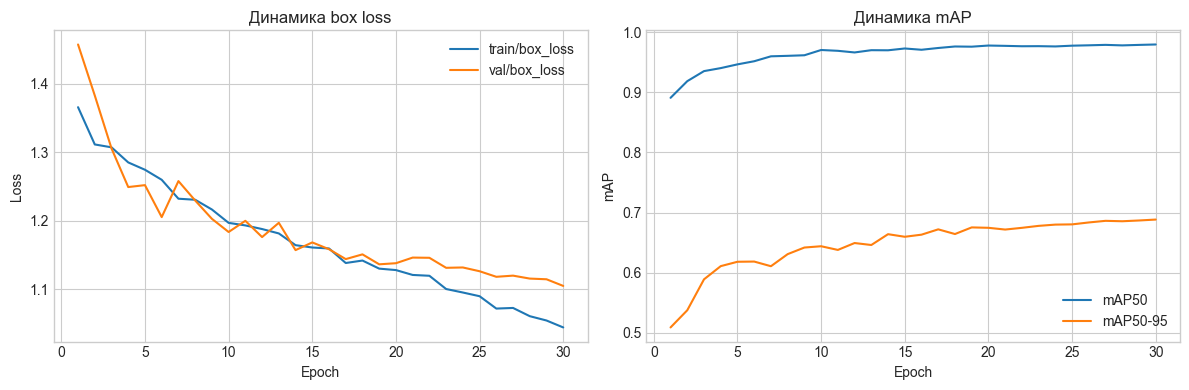

In [ ]:
df = pd.read_csv(RESULTS_CSV)

df.columns = [str(c).strip() for c in df.columns]

epoch_col = "epoch" if "epoch" in df.columns else df.columns[0]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df[epoch_col], df["train/box_loss"], label="train/box_loss")
plt.plot(df[epoch_col], df["val/box_loss"], label="val/box_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Динамика box loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df[epoch_col], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df[epoch_col], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Динамика mAP")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
images = sorted(TEST_IMAGES.glob("*.jpg"))[:10]
if not images:
    raise FileNotFoundError(f"Не найдены изображения в {TEST_IMAGES}")

model = YOLO(str(WEIGHTS))
_ = model.predict(
    source=[str(p) for p in images],
    conf=0.25,
    iou=0.7,
    device=0,
    save=True,
    project=str(PREDICT_DIR.parent),
    name=PREDICT_DIR.name,
    exist_ok=True,
    verbose=False,
)
print(f"Инференс завершен. Результаты: {PREDICT_DIR}")

Results saved to c:\Users\Egor2\\\Lab_1\runs\predict\notebook_demo_helmet
Инференс завершен. Результаты: c:\Users\Egor2\Учёба\ИИ\Lab_1\runs\predict\notebook_demo_helmet


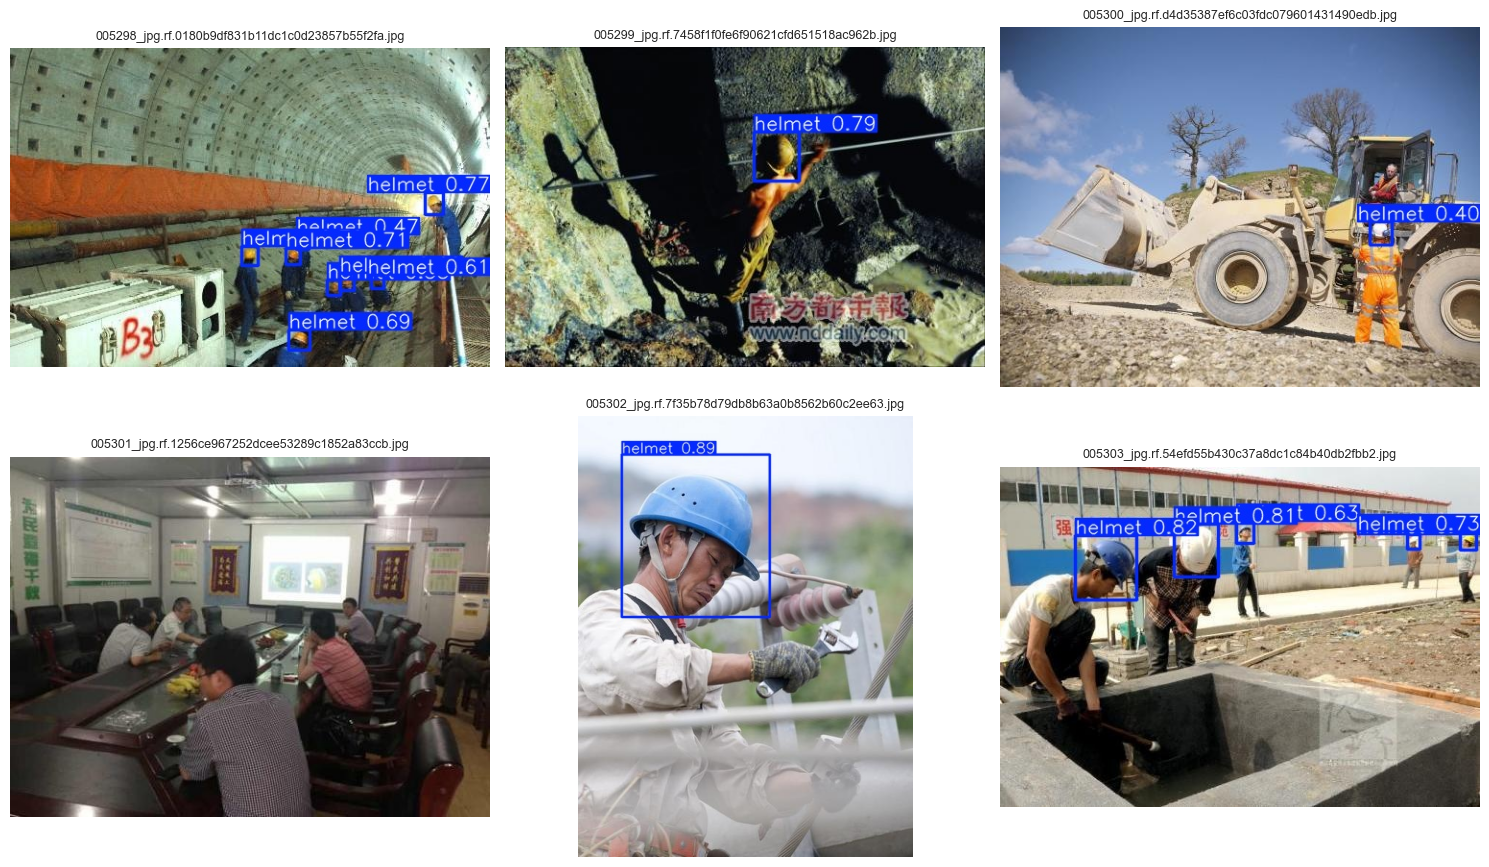

In [15]:
pred_images = sorted(PREDICT_DIR.glob("*.jpg"))[:6]

if not pred_images:
    raise FileNotFoundError(f"Не найдены предсказанные изображения в {PREDICT_DIR}")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flatten(), pred_images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

for ax in axes.flatten()[len(pred_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()